# MobileNetV2 Face Recognition — Student Template

## What you will build
A **face recognition model** trained to create a **128-number facial passport** for each face.
Instead of guessing a specific name out of a fixed list (classification), the model maps faces to a 128-number list so that:
- Photos of the **same** person produce **very similar** numbers (close together).
- Photos of **different** people produce **very different** numbers (far apart).

## Learning objectives
After completing this notebook you will understand:
1. Why creating 'facial passports' is better for recognizing new people than simple name-guessing.
2. How the **Rubber Band Rule (Triplet Loss)** helps the model learn.
3. How to build a **Siamese Network** where three identical workers share the same brain/memory.
4. How **Transfer Learning** (freezing the backbone's parameters) slashes calculations and saves laptop training time.
5. How to evaluate model quality using a simple yearbook search (**1-Nearest-Neighbour** classifier).
6. How to export the final model for deployment.

## Sections
1. Setup Environment
2. Load & Preprocess Dataset  ← **TODO 1**
3. Triplet Sampling            ← **TODO 2**
4. Model Architecture          ← **TODO 3**
5. Triplet Loss & Training     ← **TODO 4 & 5**
6. Evaluation                  ← **TODO 6**
7. Export

> **How to use this template:** Find every cell that contains a `# TODO` comment.
> Read the surrounding explanation, then replace `# YOUR CODE HERE` with working code.

## Setup Environment
Run this cell once to install any missing libraries and import everything we need.
You do **not** need to modify this cell.

In [1]:
# Install dependencies if needed (Colab pre-installs most of these)
!pip install matplotlib scikit-learn jax

import os

Importing our libraries. These are code someone else has written that we can just use directly

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import jax
from jax import numpy as jnp
import keras
from keras import layers
from keras import ops
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

print(keras.__version__)

3.13.2


## 1. Load & Preprocess Dataset

We use the **Labeled Faces in the Wild (LFW)** dataset, fetched automatically by scikit-learn.
It contains ~13,000 celebrity face photos labelled with the person's name.
We keep only people with **at least 20 photos** so every identity has enough samples for triplets.

### Preprocessing steps you must implement (TODO 1)

| Step | What | Why |
|------|------|-----|
| **1a** | Scale pixels to `[0.0, 1.0]` | Neural networks learn faster and work more stably when pixel brightness values (0-255) are converted to decimal numbers between 0.0 and 1.0. |
| **1b** | Resize to 224 × 224 | The model's image processing layers are hardwired to process images of this specific grid size. |

**NOTE** This will take some time since we are downloading the data.

In [2]:
def standardize_image(X):
  return np.astype(np.multiply(X,255.),np.uint8)

In [3]:
print("Fetching LFW dataset...")
lfw_people = fetch_lfw_people(min_faces_per_person=20, resize=1.0, color=True)

X = standardize_image(lfw_people.images)          # Loads raw uint images of shape: (N, H, W, 3)
y = lfw_people.target          # shape: (N,)           — integer class index per image
target_names = lfw_people.target_names
n_classes = target_names.shape[0]

print(f"Total images: {len(X)}")
print(f"Number of classes: {n_classes}")
print(f"Image shape before preprocessing: {X.shape}")

Fetching LFW dataset...
Total images: 3023
Number of classes: 62
Image shape before preprocessing: (3023, 125, 94, 3)


#### Visualizing the Data
Let's take a look at the first 10 images **before** they have been normalized and resized to 224x224.

Value range in X: 0 to 255
Data type: uint8


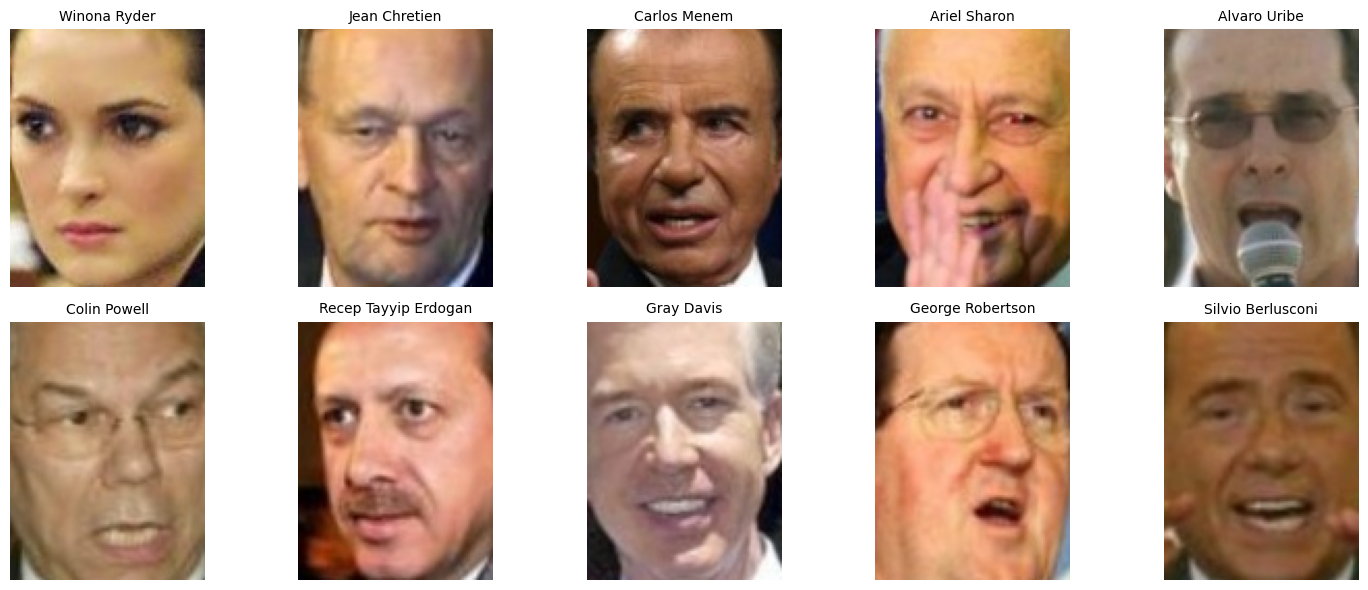

In [4]:

# Diagnostic: Check the actual range of values in the array
print(f"Value range in X: {X.min()} to {X.max()}")
print(f"Data type: {X.dtype}")

plt.figure(figsize=(15, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X[i])
    plt.title(target_names[y[i]], fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

### 1.1 Scaling Data

In [5]:
# ---------------------------------------------------------------------------
# TODO 1a: Normalise X so that pixel values are float32 in the range [0, 1].
#
#   WHY: Raw pixel values are whole numbers from 0 to 255 (representing brightness).
#        Dividing by 255.0 converts them to decimal numbers between 0.0 and 1.0,
#        which makes calculations stable and easier for the computer chip to process.
#
#   HINT: X.astype('float32') converts the datatype to decimal representation.
#         Divide the result by the maximum possible pixel value (255.0).
#
# ---------------------------------------------------------------------------
X_scaled = np.divide(X, 255.)

### 1.2: Resizing and Clip the Image

We create a function to pre-process the image which will use later in the `create_triplets` function. This will resize the image to $(224,224,3)$ -- The size required by our pre-trained model.

**Why do this as a function**: We prefer to do this only for the data that we're going to used just before training since this is a cheap operation to do computationally, but very expensive in memory since we need to store the original and modified images.

In [6]:
# This is a modification that tells jax to optimize this code.
@jax.jit
def resize_batch(X):
  """
    Infinite generator that yields one batch of (anchor, positive, negative)
    triplets per iteration.

    Args:
        X (np.ndarray): A batch of images, shape (batch_size, 125, 94, 3).

    Yields:
        Reshaped Images of shape (batch_size, 224, 224, 3)
    """
  # ---------------------------------------------------------------------------
  # TODO 1b: Resize every image to 224 × 224 pixels if not already that size.
  #
  #   WHY: The model's image processing layers are hardwired to process images
  #        of this specific grid size (224 wide by 224 high). Passing any other
  #        size will crash the model.
  #
  #   The `if` guard is provided — fill in the resize call inside it.
  #   HINT: jax.image.resize(tensor, [X.shape[0], height, width ,3]) returns a tensor;
  #         call .numpy() on it to get a NumPy array back.
  #
  ## ADDITIONAL TASK: Any value >1. should be set to 1.
  #    WHY: Sometimes the image resize functions creates values slightly greater than 1.
  #         It's important to account for those.
  #
  #   HINT: np.clip() is a function that does exactly this
  # ---------------------------------------------------------------------------
  if X.shape[1:3] != (224, 224):
      ## Resize the Image Below
      X_resized = jax.image.resize(X, (X.shape[0],224, 224,3),method="cubic") # Your code here
      # ## Clip all values less than 0 and greater than 1
      X_resized = jnp.clip(X_resized,0.,1.)
  return X_resized

#### Why split the data? (The Teacher's Analogy)

Imagine you are preparing your students for a big Final Exam.

*   **The Training Set (The Study Guide):** This is like the homework and practice problems you give students in class. They see the questions *and* the answers so they can learn the patterns. If they only ever see these exact same questions, they might just memorize the answers instead of actually learning the subject.
*   **The Validation Set (The Final Exam):** This is a set of questions the students have **never seen before**. We use this to see if they actually understood the *concepts* or if they just memorized the homework.

In AI, if a model does perfectly on the Training Set but fails the Validation Set, we call that **Overfitting**—it's the digital version of a student who memorized the textbook but can't solve a new problem!

In [7]:
# Split into training (80%) and validation (20%) sets
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print(f"Train size: {len(X_train)}  |  Val size: {len(X_val)}")

Train size: 2418  |  Val size: 605


## 2. Triplet Sampling (Selecting Groups of 3 Images)

We train our model using **triplets**: three images grouped together:

```
                  ┌─────────────────┐
Anchor (A)   ────▶│ Embedding Model │────▶ f(A) ───┐
                  └─────────────────┘              │
                  ┌─────────────────┐              ▼
Positive (P) ────▶│  (Shared Brain) │────▶ f(P) ────────▶ [ Triplet Loss ]
                  └─────────────────┘              ▲
                  ┌─────────────────┐              │
Negative (N) ────▶│  (Shared Brain) │────▶ f(N) ───┘
                  └─────────────────┘
```

The model is trained to push the Anchor closer to the Positive (same person) and farther from the Negative (different person).

### Your task (TODO 2)
Complete `create_triplets()` — a helper function (generator) that yields a batch of triplets.
For each item in the batch:
1. Pick a random person.  
2. Pick two different images of that person → **Anchor** and **Positive**.  
3. Pick an image of a *different* person → **Negative**.

The surrounding infrastructure is provided for you.

In [8]:
def create_triplets(X, y, batch_size=32):
    """
    Infinite generator that yields one batch of (anchor, positive, negative)
    triplets per iteration.

    Args:
        X (np.ndarray): All images, shape (N, 224, 224, 3).
        y (np.ndarray): Integer class labels, shape (N,).
        batch_size (int): Number of triplets per batch.

    Yields:
        Tuple of (inputs_dict, dummy_labels) where inputs_dict has keys
        'anchor', 'positive', 'negative' and dummy_labels is all zeros.
    Note: We return dummy labels to make this fit what keras expects for its model.fit function
    """
    while True:
        anchors   = []
        positives = []
        negatives = []

        unique_labels = np.unique(y)

        while len(anchors) < batch_size:
            # Pick a random person
            random_label = np.random.choice(unique_labels)
            label_indices = np.where(y == random_label)[0]

            # Ensure they have enough images for a pair
            if len(label_indices) < 2:
                continue

            # -------------------------------------------------------------------
            # TODO 2a: Randomly pick 2 DIFFERENT indices from label_indices.
            #          These will be the Anchor index (idx_a) and the Positive
            #          index (idx_p).
            #
            #   HINT: np.random.choice(array, size, replace=False) picks `size`
            #         elements without repetition (so a photo isn't compared to itself).
            #         Unpack the result into two variables: idx_a, idx_p
            # -------------------------------------------------------------------
            idx_a, idx_p = np.random.choice(label_indices, size=2, replace=False)

            # --- Negative (different person) ---------------------------------

            # -------------------------------------------------------------------
            # TODO 2b: Pick a random label that is DIFFERENT from random_label.
            #
            #   HINT: y[y != random_label] filters our list of names (y) to isolate
            #         everyone except the current target person.
            # -------------------------------------------------------------------
            negative_label = np.random.choice(y[y != random_label])

            # Pick a random image index that belongs to negative_label.
            idx_n = np.random.choice(np.where(y == negative_label)[0])

            # -------------------------------------------------------------------
            # TODO 2c: Append the three images to their respective lists.
            #
            #   X[idx_a] is the anchor image, X[idx_p] the positive, X[idx_n]
            #   the negative. Append each to the correct list above.
            # -------------------------------------------------------------------
            anchors.append(X[idx_a])
            positives.append(X[idx_p])
            negatives.append(X[idx_n])

        # -------------------------------------------------------------------
        # TODO 2d: Before returning our images we need to resize them using
        #          the function we defined earlier -- resize_batch()
        # -------------------------------------------------------------------
        anchors = resize_batch(jnp.array(anchors))
        positives = resize_batch(jnp.array(positives))
        negatives = resize_batch(jnp.array(negatives))

        yield (
            {
                "anchor":   anchors,
                "positive": positives,
                "negative": negatives,
            },
            np.zeros((batch_size, 1), dtype="float32")
        )

# Create the generators directly
train_gen = create_triplets(X_train, y_train, batch_size=32)
val_gen = create_triplets(X_val, y_val, batch_size=32)

print("Backend-agnostic Triplet generators created successfully.")

Backend-agnostic Triplet generators created successfully.


### Visualizing what this data looks like:
We will plot out 5 sets of triplets to see what they look like and how the pre-processing and resizing has affected them

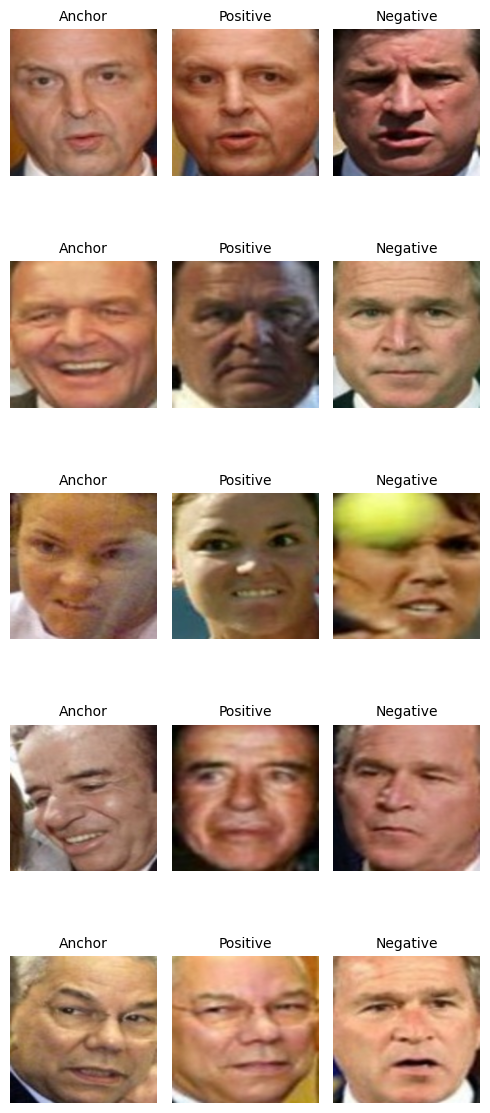

In [9]:
plt.figure(figsize=(5, 12))
images = next(train_gen)[0]
for i in range(0,15,3):
    ## Anchor
    plt.subplot(5, 3, i + 1)
    plt.imshow(images['anchor'][i])
    plt.title("Anchor", fontsize=10)
    plt.axis('off')
    # Postive
    plt.subplot(5, 3, i + 2)
    plt.imshow(images['positive'][i])
    plt.title("Positive", fontsize=10)
    plt.axis('off')
    # Postive
    plt.subplot(5, 3, i + 3)
    plt.imshow(images['negative'][i])
    plt.title("Negative", fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

## 3. Model Architecture (Building the Model)

We use **Transfer Learning**: we start with MobileNetV2 pre-trained on 1.2 million images, freeze its weights, and add a small custom head that produces our 128-number passport.

### ⚡ Computational Cost & Freezing the Brain
- **Model Settings (Parameters)**: MobileNetV2 has **2.2 million settings (parameters)**. This smaller size is essential for laptops and edge devices with limited calculation speed and memory.
- **Freezing the Brain (`trainable = False`)**: The backbone (main visual cortex) has already learned general visual features (like shapes, lines, and textures). By freezing these layers, we avoid recalculating adjustments for those 2.2M parameters. We only train our custom projection layer (~160,000 parameters). This cuts calculations significantly, shortening training from hours to minutes!

```
Input (224×224×3)
    │
    ▼
MobileNetV2 backbone  ← frozen (visual cortex pre-trained on ImageNet)
    │
    ▼
GlobalAveragePooling2D  ← collapses spatial shapes to flat lists
    │
    ▼
Dense(128)              ← learns to shrink info to 128 numbers
    │
    ▼
L2 Normalise            ← scales passport length to exactly 1.0
```

The same `embedding_model` is applied to all three Siamese inputs (Anchor, Positive, Negative),
**sharing weights** — this is the defining feature of a Siamese Network (three workers sharing the exact same brain).

### Your task (TODO 3)
Fill in the body of `get_embedding_model()`.

In [34]:
def get_embedding_model():
    """
    Build and return the embedding model.

    Returns:
        keras.Model: Maps (batch, 224, 224, 3) → (batch, 128) L2-normalised embeddings.
    """
    # -----------------------------------------------------------------------
    # TODO 3a: Load the MobileNetV2 backbone.
    #
    #   We load the pre-made MobileNetV2. Think of this as the main visual
    #   cortex of the model. We discard its final classification head
    #   (include_top=False) that guesses specific labels like 'dog' or 'cat',
    #   because we want to output our custom facial passport instead.
    #
    #   Fill in the three arguments:
    #     input_shape : tuple — the image dimensions (height, width, channels)
    #     include_top : bool  — do we want the classification head?
    #     weights     : str   — which pre-trained weights to load?
    # -----------------------------------------------------------------------
    base_model = keras.applications.MobileNetV3Small(
        input_shape=(224, 224, 3),   # YOUR CODE HERE
        include_top=False,   # YOUR CODE HERE
        weights="imagenet"        # YOUR CODE HERE
    )

    # -----------------------------------------------------------------------
    # TODO 3b: Freeze the backbone.
    #
    #   WHY: We freeze it (trainable = False) so we don't adjust the visual
    #        features already learned by the backbone. This saves us from doing
    #        millions of backward-pass adjustments, saving computation time.
    #
    #   Set base_model.trainable to the correct boolean value.
    # -----------------------------------------------------------------------
    base_model.trainable = False  # YOUR CODE HERE

    # -----------------------------------------------------------------------
    # TODO 3c: Build the embedding head.
    #
    #   Follow these steps in order:
    #   1. Define an Input layer with shape (224, 224, 3).
    #   2. Apply MobileNetV2's own preprocessing (rescales to [-1, 1]):
    #        x = keras.applications.mobilenet_v2.preprocess_input(inputs * 255.0)
    #      (We multiply by 255 because our inputs are already in [0,1].)
    #   3. Pass x through base_model (with training=False so BatchNorm
    #      layers behave correctly at inference time).
    #   4. Apply layers.GlobalAveragePooling2D() to collapse the 7×7 map.
    #   5. Apply layers.Dense(128) — no activation.
    #   6. L2-normalise with the lower level keras math library -- keras.ops
    #           This is specifically done using ops.normalize(x)
    #
    #   HINT: Chain the layers like this:
    #     inputs = layers.Input((224, 224, 3))
    #     x = <preprocessing>(inputs)
    #     x = <base_model>(x, training=False)
    #     x = <pooling>(x)
    #     x = <dense1 with ReLU>(x)
    #     x = <dense2>(x)
    #     outputs = <l2_norm>(x)
    # -----------------------------------------------------------------------
    inputs  = layers.Input((224, 224, 3))  # YOUR CODE HERE
    x       = base_model(inputs*255., training=False)  # YOUR CODE HERE  (backbone)
    x       = layers.GlobalAveragePooling2D()(x)  # YOUR CODE HERE  (GlobalAveragePooling2D)
    x       = layers.Dense(512, activation='relu')(x)  # YOUR CODE HERE  (Dense 512)
    x       = layers.Dense(256)(x)  # YOUR CODE HERE  (Dense 128)
    outputs = ops.normalize(x)  # YOUR CODE HERE  (L2 normalise)

    return keras.Model(inputs, outputs, name="embedding_model")


# Build the embedding model and print a summary
embedding_model = get_embedding_model()
embedding_model.summary()

# ---------------------------------------------------------------------------
# Provided: Siamese Network — three Input layers that all share the same
# embedding_model weights.
# ---------------------------------------------------------------------------
anchor_input   = layers.Input((224, 224, 3), name="anchor")
positive_input = layers.Input((224, 224, 3), name="positive")
negative_input = layers.Input((224, 224, 3), name="negative")

anchor_embedding   = embedding_model(anchor_input)
positive_embedding = embedding_model(positive_input)
negative_embedding = embedding_model(negative_input)

print("\nSiamese branches built. Each branch shares the same embedding_model weights.")

Model: "embedding_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_16 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply_32 (Multiply)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 512)            │       295,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalize_6 (Normalize)         │ (None, 256)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,365,872 (5.21 MB)

 Trainable params: 426,752 (1.63 MB)

 Non-trainable params: 939,120 (3.58 MB)


Siamese branches built. Each branch shares the same embedding_model weights.


## 4. Triplet Loss
### 💡 Analogy: The Rubber Band Rule
- Think of **Anchor** and **Positive** as friends. We want to pull them together.
- Think of **Anchor** and **Negative** as strangers. We want to push them apart.
- Triplet loss acts like an elastic rubber band between Anchor and Positive, and a stiff wooden peg between Anchor and Negative. It penalizes the network if they aren't separated by at least a safety **margin** ($\alpha$).

### The Triplet Loss formula

$$
\mathcal{L}(A, P, N) = \max\!\Bigl(\,\underbrace{\|f(A)-f(P)\|^2}_{\text{positive distance}}
                                  -\underbrace{\|f(A)-f(N)\|^2}_{\text{negative distance}}
                                  + \alpha,\; 0\Bigr)
$$

Where:
- $f(\cdot)$ is the embedding model.
- $\alpha$ is the **margin** — a gap we force between the positive and negative distances.
- The $\max(\cdot, 0)$ clamp ensures we only penalise "easy" triplets that already satisfy
  the margin.

In plain English: *push the anchor–positive distance below the anchor–negative distance
by at least a margin $\alpha$.*

### Your tasks
- **TODO 4** — Implement `TripletLossLayer.call()`.

In [35]:
class TripletLossLayer(layers.Layer):
    """
    Custom Keras layer that computes the triplet loss and registers it
    via self.add_loss() so Keras handles backpropagation automatically.
    """

    def __init__(self, margin=0.2, **kwargs):
        super().__init__(**kwargs)
        self.margin = margin   # α in the formula above

    def call(self, inputs):
        anchor, positive, negative = inputs

        # -------------------------------------------------------------------
        # TODO 4a: Compute the POSITIVE distance — the squared distance
        #          between the anchor embedding and the positive embedding.
        #
        #   Formula: pos_dist = sum( (anchor - positive)^2 )  per sample
        #
        #   HINT: This is like finding the distance between two points on a graph
        #         for each of the 128 numbers (find the difference, square it, and sum them up).
        #         Since these are pure math operations, we use the low-level keras.ops library.
        #
        #         ops.square(x)             → element-wise square
        #         ops.sum(x, axis=-1) → sum across the embedding dimension
        # -------------------------------------------------------------------
        pos_dist = ops.sum(ops.square(anchor - positive), axis=-1)

        # -------------------------------------------------------------------
        # TODO 4b: Compute the NEGATIVE distance — the squared distance
        #          between the anchor embedding and the negative embedding.
        #
        #   Same distance formula as above but using `negative` instead of `positive`.
        # -------------------------------------------------------------------
        neg_dist = ops.sum(ops.square(anchor - negative), axis=-1)

        # -------------------------------------------------------------------
        # TODO 4c: Compute basic_loss for each sample in the batch.
        #
        #   Formula: basic_loss = pos_dist - neg_dist + self.margin
        #
        #   This will be a tensor of shape (batch_size,) — one loss value
        #   per triplet.
        # -------------------------------------------------------------------
        basic_loss = pos_dist - neg_dist + self.margin

        # -------------------------------------------------------------------
        # TODO 4d: Clamp at zero (ignore easy triplets) and average over the
        #          batch, then register as a Keras loss.
        #
        #   Formula: loss = mean( max(basic_loss, 0) )
        #
        #   HINT: If a triplet is already correct (loss < 0), we clamp it to 0.0
        #         so the model doesn't waste effort adjusting settings it already knows.
        #         ops.maximum(x, 0.0)    → element-wise max with 0
        #         ops.mean(x)     → mean over all elements
        #
        #   After computing `loss`, call  self.add_loss(loss)  so Keras
        #   includes it in the optimisation step.
        # -------------------------------------------------------------------
        loss = ops.mean(ops.maximum(basic_loss, 0.0))
        self.add_loss(loss)
        return loss


# ---------------------------------------------------------------------------
# Provided: wire the Siamese embeddings into the loss layer and compile.
# ---------------------------------------------------------------------------
loss_layer = TripletLossLayer(margin=0.2)(
    [anchor_embedding, positive_embedding, negative_embedding]
)

trainable_siamese_model = keras.Model(
    inputs=[anchor_input, positive_input, negative_input],
    outputs=loss_layer
)

trainable_siamese_model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ anchor (InputLayer) │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positive            │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ negative            │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_model     │ (None, 256)       │  1,365,872 │ anchor[0][0],     │
│ (Functional)        │                   │            │ positive[0][0],   │
│                     │                   │            │ negative[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ triplet_loss_layer… │ ()                │          0 │ embedding_model[… │
│ (TripletLossLayer)  │                   │            │ embedding_model[… │
│                     │                   │            │ embedding_model[… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,365,872 (5.21 MB)

 Trainable params: 426,752 (1.63 MB)

 Non-trainable params: 939,120 (3.58 MB)

## 5. Train the model
Finally we train the model over a set of **epochs** (or rounds)

### Your tasks
- **TODO 5** — Fill in the `model.fit()` training arguments.


In [36]:
## `model.compile` tells keras to put everything together
trainable_siamese_model.compile(optimizer='adam')

# ---------------------------------------------------------------------------
# TODO 5: Fill in the training arguments.
#
#   - steps_per_epoch : how many batches to draw from train_gen per epoch.
#                       Start with 20 (quick experiment).
#   - epochs          : how many full passes over steps_per_epoch batches.
#                       Start with 10.
#   - validation_data : the validation generator (val_gen).
#   - validation_steps: how many batches to draw from val_gen per epoch.
#                       Start with 5.
# ---------------------------------------------------------------------------
print("Starting training...")
history = trainable_siamese_model.fit(
    train_gen,
    steps_per_epoch=20,    # YOUR CODE HERE
    epochs=25,             # YOUR CODE HERE
    validation_data=val_gen,    # YOUR CODE HERE
    validation_steps=5,    # YOUR CODE HERE
    verbose=1
)

Starting training...
Epoch 1/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 35s 628ms/step - loss: 0.1313 - val_loss: 0.0978
Epoch 2/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 113ms/step - loss: 0.0900 - val_loss: 0.0881
Epoch 3/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 122ms/step - loss: 0.0848 - val_loss: 0.1045
Epoch 4/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 0.0787 - val_loss: 0.0922
Epoch 5/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - loss: 0.0718 - val_loss: 0.0943
Epoch 6/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 129ms/step - loss: 0.0760 - val_loss: 0.0778
Epoch 7/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 136ms/step - loss: 0.0662 - val_loss: 0.0692
Epoch 8/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - loss: 0.0542 - val_loss: 0.0644
Epoch 9/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - loss: 0.0598 - val_loss: 0.0927
Epoch 10/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 0.0633 - val_loss: 0.0872
Epoch 11/25
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - loss: 0.0654 - val_loss: 0.0718
Epoch 12/25
20/20 ━━━━━━━━━━━━━━━━━

## 6. Evaluation (Testing the Model)

We evaluate the quality of our face passports using a **yearbook lookup (1-Nearest-Neighbour classifier)**:

1. Generate face passports for every training image.
2. For each validation image, find the single closest passport in our training database.
3. Match the validation identity to that closest training neighbor's name.
4. Compare predictions to actual names to calculate accuracy.

This tells us how well-separated our different faces are in the 128-number space.

### Your task (TODO 6)

In [37]:
# We need to resize the entire training set before we can test our model.
# To make sure we don't crash the system due to lack of GPU memory we run this
# on CPU.
# Get the first CPU device
cpu_device = jax.devices('cpu')[0]

with jax.default_device(cpu_device):
  X_resized = resize_batch(X_train)
  X_val = resize_batch(X_val)

In [ ]:
# ---------------------------------------------------------------------------
# TODO 6a: Generate facial passports (embeddings) for the TRAINING and VALIDATION sets.
#
#   Use embedding_model.predict() — NOT trainable_siamese_model.
#   Pass batch_size=32 to avoid running out of memory (OOM).
#   Store results in  train_embeddings  and  val_embeddings.
# ---------------------------------------------------------------------------

print("Generating embeddings for training set...")
train_embeddings = embedding_model.predict(X_resized, batch_size=32)

print("Generating embeddings for validation set...")
val_embeddings = embedding_model.predict(X_val, batch_size=32)

# ---------------------------------------------------------------------------
# TODO 6b: Train a 1-NN (yearbook lookup) classifier on the training embeddings.
#
#   Create a KNeighborsClassifier with:
#     n_neighbors=1   (find the single nearest yearbook neighbor)
#     metric='euclidean'
#   Then call .fit() with train_embeddings and y_train.
# ---------------------------------------------------------------------------
knn = KNeighborsClassifier(n_neighbors=1, metric='euclidean')
knn.fit(train_embeddings, y_train)

# ---------------------------------------------------------------------------
# TODO 6c: Predict labels for the validation embeddings, then compute
#           and print the accuracy.
#
#   HINT:
#     knn.predict(val_embeddings)          → predicted labels
#     accuracy_score(y_true, y_pred)       → fraction correct
# ---------------------------------------------------------------------------
y_pred = knn.predict(val_embeddings)
acc    = accuracy_score(y_val, y_pred)

print(f"\n{'─'*50}")
print(f"Validation Accuracy (1-NN on Embeddings): {acc:.4f}")
print(f"{'─'*50}\n")

Generating embeddings for training set...


## 7. Export to TF SavedModel

We export only the **embedding model** (not the Siamese training wrapper) to storage so we can download it and use it on other devices and with other applications.

You do **not** need to modify this cell.

In [13]:
embedding_model.save("./facenet.keras")